In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import itertools
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, cohen_kappa_score
from scipy.stats import chi2_contingency

In [32]:
df = pd.read_parquet("../data/derived/clean_core.parquet")

In [33]:
pd.set_option('display.max_rows', None)
null_pct = df.isnull().mean().mul(100).round(2).reset_index()
null_pct.columns = ['column', 'null_pct']
display(null_pct.sort_values('null_pct', ascending=False))

,column,null_pct
40,current_tech,90.47
58,job_sat_num,87.11
30,work_week_hrs_clean,85.94
29,work_week_hrs,85.84
55,work_exp,79.51
32,learn_code_online,77.22
49,learn_code_online_count,77.22
41,ai_use,75.53
50,coding_activities_count,74.92
33,coding_activities,74.92


In [34]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

null_by_year = (
    df.groupby('survey_year')
    .apply(lambda x: x.isnull().mean().mul(100).round(2))
    .T
)

display(null_by_year)

survey_year,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
row_id,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
response_id,100.00,100.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
country,3.09,0.90,0.00,0.42,0.15,0.60,0.00,2.04,1.36,9.94,27.96
country_clean,3.11,0.95,0.27,0.50,0.30,0.65,0.06,2.09,1.43,10.01,28.02
region,3.11,0.95,0.31,0.50,0.30,0.65,0.06,2.09,1.43,10.01,28.02
age,0.98,1.24,100.00,34.68,10.88,29.50,1.24,3.17,0.00,0.00,0.00
age_mid,2.28,1.24,100.00,34.68,10.95,29.54,1.93,3.88,0.50,0.49,0.77
age_group,2.28,1.24,100.00,34.68,10.95,29.54,1.93,3.88,0.50,0.49,0.77
gender,1.31,0.79,31.80,34.78,3.91,21.57,1.38,3.30,100.00,100.00,100.00
ethnicity,100.00,100.00,100.00,41.86,13.74,28.72,4.76,5.18,100.00,100.00,100.00


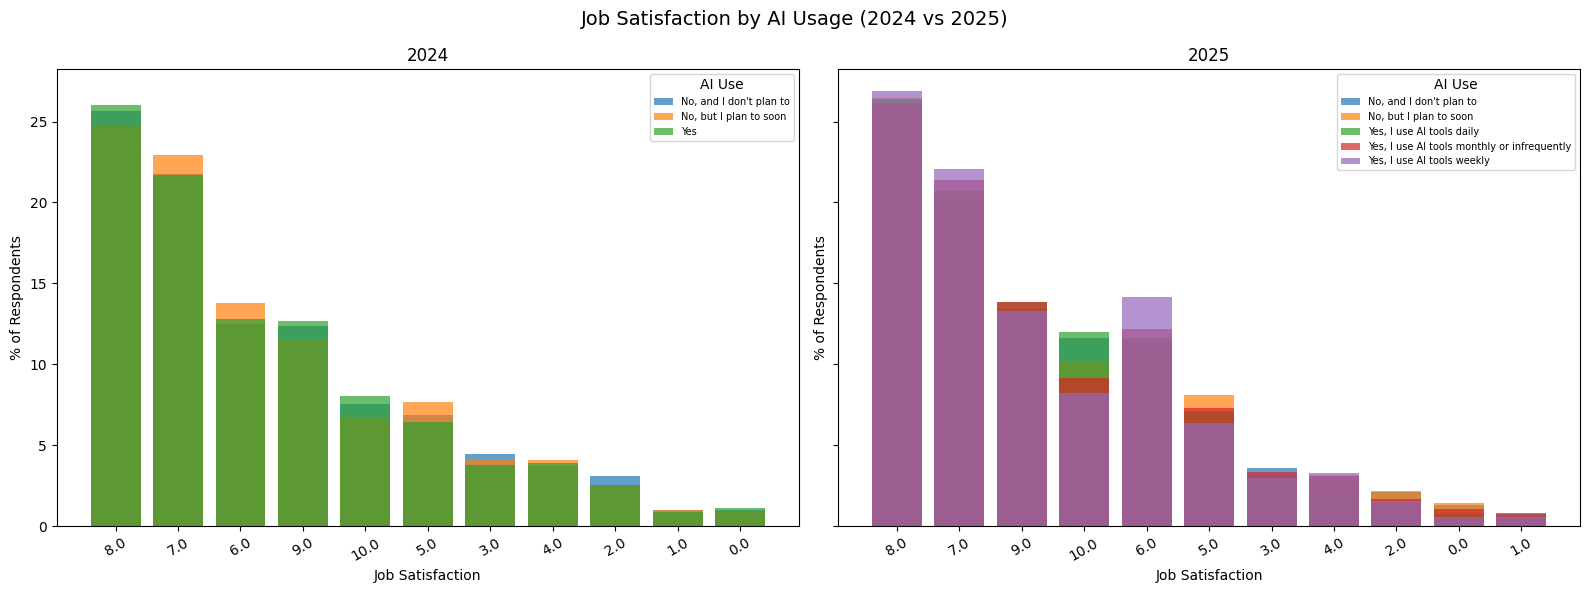

In [35]:
ai_sat = df[
    df['survey_year'].isin([2024, 2025])
    & df['ai_use'].notna()
    & df['job_sat'].notna()
].copy()

sat_by_ai = (
    ai_sat.groupby(['survey_year', 'ai_use'])['job_sat']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .reset_index(name='pct')
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
fig.suptitle('Job Satisfaction by AI Usage (2024 vs 2025)', fontsize=14)

for ax, year in zip(axes, [2024, 2025]):
    subset = sat_by_ai[sat_by_ai['survey_year'] == year]
    for ai_group, grp in subset.groupby('ai_use'):
        ax.bar(grp['job_sat'], grp['pct'], label=ai_group, alpha=0.7)
    ax.set_title(str(year))
    ax.set_xlabel('Job Satisfaction')
    ax.set_ylabel('% of Respondents')
    ax.legend(title='AI Use', fontsize=7)
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

In [36]:
cols_to_drop = [
    # Never or barely available across years
    'ethnicity',
    'student',
    'undergrad_major',
    'age_first_code',
    'age_first_code_clean',
    'job_seek',
    'work_week_hrs',
    'work_week_hrs_clean',
    'learn_code_online',
    'learn_code_online_count',
    'coding_activities',
    'coding_activities_count',
    'misc_tech',
    'misc_tech_count',
    'webframe',
    'webframe_count',
    'op_sys_prof',
    'op_sys_prof_count',
    'current_tech',
    'ai_use',
    'ai_sent',
    
    'learn_code',
    'learn_code_count',
    'work_exp',
    'age_mid',
    

    'cpi_u',
    'is_comp_analysis_sample',
    'is_comp_model_core',
    'is_comp_model_tech_rich',
    'is_comp_model_ai_era',
    'is_comp_model_extended',
    'is_comp_model_sample',
    'response_id',
    'main_branch',
    'gender',
    'country'
    
    

  
]

df_clean = df.drop(columns=cols_to_drop)
print(f"Columns remaining: {len(df_clean.columns)}")
print(df_clean.columns.tolist())

Columns remaining: 47
['row_id', 'survey_year', 'country_clean', 'region', 'age', 'age_group', 'employment', 'employment_group', 'is_employed', 'is_professional', 'education', 'education_clean', 'org_size', 'org_size_clean', 'dev_type', 'industry', 'remote', 'remote_group', 'language', 'database', 'platform', 'language_count', 'database_count', 'platform_count', 'years_code', 'years_code_clean', 'years_code_pro', 'professional_experience_years', 'job_sat', 'job_sat_num', 'comp', 'comp_usd_clean', 'log_comp_usd_clean', 'comp_real_2025', 'log_comp_real_2025', 'role_family_count', 'role_back_end', 'role_data_ml', 'role_desktop_enterprise', 'role_devops_cloud', 'role_front_end', 'role_full_stack', 'role_management', 'role_mobile', 'role_other', 'role_qa_testing', 'role_student_academic']


In [37]:
df_clean = df_clean[~df_clean['survey_year'].isin([2021, 2022, 2023])]
print(df_clean['survey_year'].unique())
print(f"Rows remaining: {len(df_clean):,}")

[2015 2016 2017 2018 2019 2020 2024 2025]
Rows remaining: 500,335


In [38]:
for year in sorted(df_clean['survey_year'].unique()):
    unique_vals = df_clean[df_clean['survey_year'] == year]['job_sat'].dropna().unique()
    print(f"\n{year}:")
    for val in unique_vals:
        print(f"  {val}")


2015:
  I'm somewhat satisfied with my job
  I'm neither satisfied nor dissatisfied with my job
  I love my job
  I'm somewhat dissatisfied with my job
  I hate my job
  Other (please specify)

2016:
  I love my job
  I don't have a job
  I'm somewhat satisfied with my job
  I'm somewhat dissatisfied with my job
  I'm neither satisfied nor dissatisfied
  Other (please specify)
  I hate my job

2017:
  9.0
  3.0
  8.0
  6.0
  7.0
  5.0
  4.0
  10.0
  2.0
  0.0
  1.0

2018:
  Extremely satisfied
  Moderately dissatisfied
  Moderately satisfied
  Neither satisfied nor dissatisfied
  Slightly satisfied
  Slightly dissatisfied
  Extremely dissatisfied

2019:
  Slightly satisfied
  Slightly dissatisfied
  Neither satisfied nor dissatisfied
  Very satisfied
  Very dissatisfied

2020:
  Slightly satisfied
  Very dissatisfied
  Slightly dissatisfied
  Very satisfied
  Neither satisfied nor dissatisfied

2024:
  8.0
  5.0
  10.0
  6.0
  9.0
  4.0
  7.0
  3.0
  2.0
  1.0
  0.0

2025:
  10.0
  9.

In [39]:
# Map all years to a consistent 1-5 ordinal scale:
#   1 = Very Dissatisfied  2 = Dissatisfied  3 = Neutral  4 = Satisfied  5 = Very Satisfied
#
# 2015/2016: 5-point text  |  2018: 7-point text (collapsed to 5)
# 2019/2020: 5-point text  |  2017/2024/2025: 0-10 numeric (binned)

SAT_MAP = {
    # 2015 & 2016
    "I hate my job":                                         1,
    "I'm somewhat dissatisfied with my job":                2,
    "I'm neither satisfied nor dissatisfied with my job":   3,
    "I'm neither satisfied nor dissatisfied":               3,
    "I'm somewhat satisfied with my job":                   4,
    "I love my job":                                         5,
    "I don't have a job":                                   np.nan,
    "Other (please specify)":                                np.nan,

    # 2018 (7-point collapsed to 5)
    "Extremely dissatisfied":           1,
    "Moderately dissatisfied":          2,
    "Slightly dissatisfied":            2,
    "Neither satisfied nor dissatisfied": 3,
    "Slightly satisfied":               4,
    "Moderately satisfied":             4,
    "Extremely satisfied":              5,

    # 2019 & 2020
    "Very dissatisfied":    1,
    # "Slightly dissatisfied" already mapped above
    # "Neither satisfied nor dissatisfied" already mapped above
    # "Slightly satisfied" already mapped above
    "Very satisfied":       5,
}

def standardize_job_sat(row):
    val = row["job_sat"]
    year = row["survey_year"]

    if pd.isna(val):
        return np.nan

    # 2017, 2024, 2025: 0-10 numeric â€” bin to 1-5
    if year in [2017, 2024, 2025]:
        try:
            v = float(val)
        except:
            return np.nan
        if v <= 1:   return 1
        elif v <= 4: return 2
        elif v <= 6: return 3
        elif v <= 8: return 4
        else:        return 5

    return SAT_MAP.get(val, np.nan)

df_clean["job_sat_std"] = df_clean.apply(standardize_job_sat, axis=1)

# Sanity check
print(df_clean.groupby("survey_year")["job_sat_std"].agg(["mean", "median", "count"]))
print()
print(df_clean["job_sat_std"].value_counts().sort_index())


                 mean  median  count
survey_year                         
2015         3.999938     4.0  16004
2016         3.931820     4.0  39425
2017         3.751090     4.0  40376
2018         3.614210     4.0  69276
2019         3.685257     4.0  70988
2020         3.631411     4.0  45194
2024         3.734773     4.0  29126
2025         3.852606     4.0  26670

job_sat_std
1.0     14057
2.0     46836
3.0     44968
4.0    140509
5.0     90689
Name: count, dtype: int64


In [40]:
df_model = df_clean[df_clean['job_sat_std'].notna()].copy()

print(f"Rows before: {len(df_clean):,}")
print(f"Rows after:  {len(df_model):,}")
print(f"Dropped:     {len(df_clean) - len(df_model):,}")
print()
print(df_model.groupby('survey_year')['job_sat_std'].agg(['mean', 'median', 'count']))

Rows before: 500,335
Rows after:  337,059
Dropped:     163,276

                 mean  median  count
survey_year                         
2015         3.999938     4.0  16004
2016         3.931820     4.0  39425
2017         3.751090     4.0  40376
2018         3.614210     4.0  69276
2019         3.685257     4.0  70988
2020         3.631411     4.0  45194
2024         3.734773     4.0  29126
2025         3.852606     4.0  26670


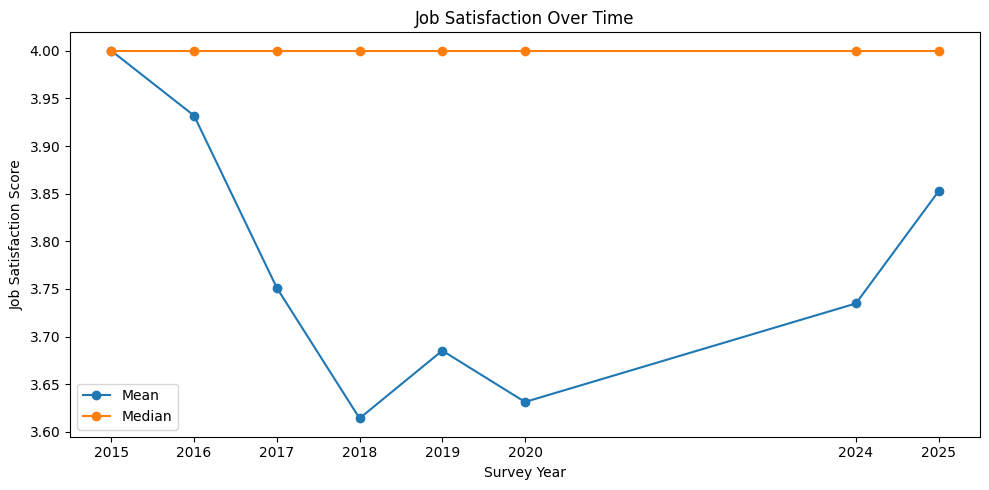

In [41]:
sat_by_year = (
    df_model.groupby('survey_year')['job_sat_std']
    .agg(['mean', 'median'])
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(sat_by_year['survey_year'], sat_by_year['mean'], marker='o', label='Mean')
ax.plot(sat_by_year['survey_year'], sat_by_year['median'], marker='o', label='Median')

ax.set_title('Job Satisfaction Over Time')
ax.set_xlabel('Survey Year')
ax.set_ylabel('Job Satisfaction Score')
ax.legend()
ax.set_xticks(sat_by_year['survey_year'])
plt.tight_layout()
plt.show()

In [42]:
print(df_model.groupby('survey_year').agg(
    total_rows=('job_sat', 'size'),
    non_null=('job_sat_std', lambda x: x.notna().sum()),
    null=('job_sat_std', lambda x: x.isna().sum()),
    pct_null=('job_sat_std', lambda x: round(x.isna().mean() * 100, 2)),
    mean_sat=('job_sat_std', 'mean'),
    median_sat=('job_sat_std', 'median'),
))

             total_rows  non_null  null  pct_null  mean_sat  median_sat
survey_year                                                            
2015              16004     16004     0       0.0  3.999938         4.0
2016              39425     39425     0       0.0  3.931820         4.0
2017              40376     40376     0       0.0  3.751090         4.0
2018              69276     69276     0       0.0  3.614210         4.0
2019              70988     70988     0       0.0  3.685257         4.0
2020              45194     45194     0       0.0  3.631411         4.0
2024              29126     29126     0       0.0  3.734773         4.0
2025              26670     26670     0       0.0  3.852606         4.0


In [43]:
df_clean['sat_missing'] = df_clean['job_sat_std'].isna().astype(int)
print(df_clean.groupby('survey_year')['sat_missing'].mean())
print(df_clean.groupby('employment_group')['sat_missing'].mean())
print(df_clean.groupby('region')['sat_missing'].mean())

survey_year
2015    0.386491
2016    0.296359
2017    0.214352
2018    0.299216
2019    0.201332
2020    0.298894
2024    0.554900
2025    0.457828
Name: sat_missing, dtype: float64
employment_group
Employed full-time        0.146973
Employed part-time        0.368359
Independent / contract    0.287122
Not employed              0.976526
Other                     0.459012
Student                   0.970444
Name: sat_missing, dtype: float64
region
Africa      0.437049
Americas    0.255103
Asia        0.365735
Europe      0.284995
Oceania     0.268346
Name: sat_missing, dtype: float64


mostly full-time employed professionals, 

by removing all jo_sat that are null, we can see that 97% of students and unemployed left job sat na. 
additionally almost half of people from africa left job_sat NA
modeling will underrepresent these groups 

In [44]:
null_by_year = (
    df_model.groupby('survey_year')
    .apply(lambda x: x.isnull().mean().mul(100).round(2))
    .T
)

display(null_by_year)

survey_year,2015,2016,2017,2018,2019,2020,2024,2025
row_id,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
country_clean,1.26,0.41,0.13,0.07,0.13,0.05,0.04,3.15
region,1.26,0.41,0.15,0.07,0.13,0.05,0.04,3.15
age,0.22,0.55,100.00,19.64,8.96,19.56,0.00,0.00
age_group,0.90,0.55,100.00,19.64,9.01,19.59,0.16,0.26
employment,0.22,0.11,0.00,0.00,0.47,0.28,0.00,0.00
employment_group,0.22,0.11,0.00,0.00,0.08,0.28,0.00,0.00
is_employed,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
is_professional,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
education,7.90,4.86,0.00,1.53,1.77,1.82,0.00,0.09


In [45]:
overall_null = df_model.isnull().mean().mul(100).round(2).reset_index()
overall_null.columns = ['column', 'overall_null_pct']
overall_null = overall_null.sort_values('overall_null_pct', ascending=False)

# flag columns over 50% null overall
majority_null = overall_null[overall_null['overall_null_pct'] > 50]
print("Columns with >50% nulls overall:")
print(majority_null.to_string(index=False))

Columns with >50% nulls overall:
     column  overall_null_pct
job_sat_num             71.47
   industry             56.91


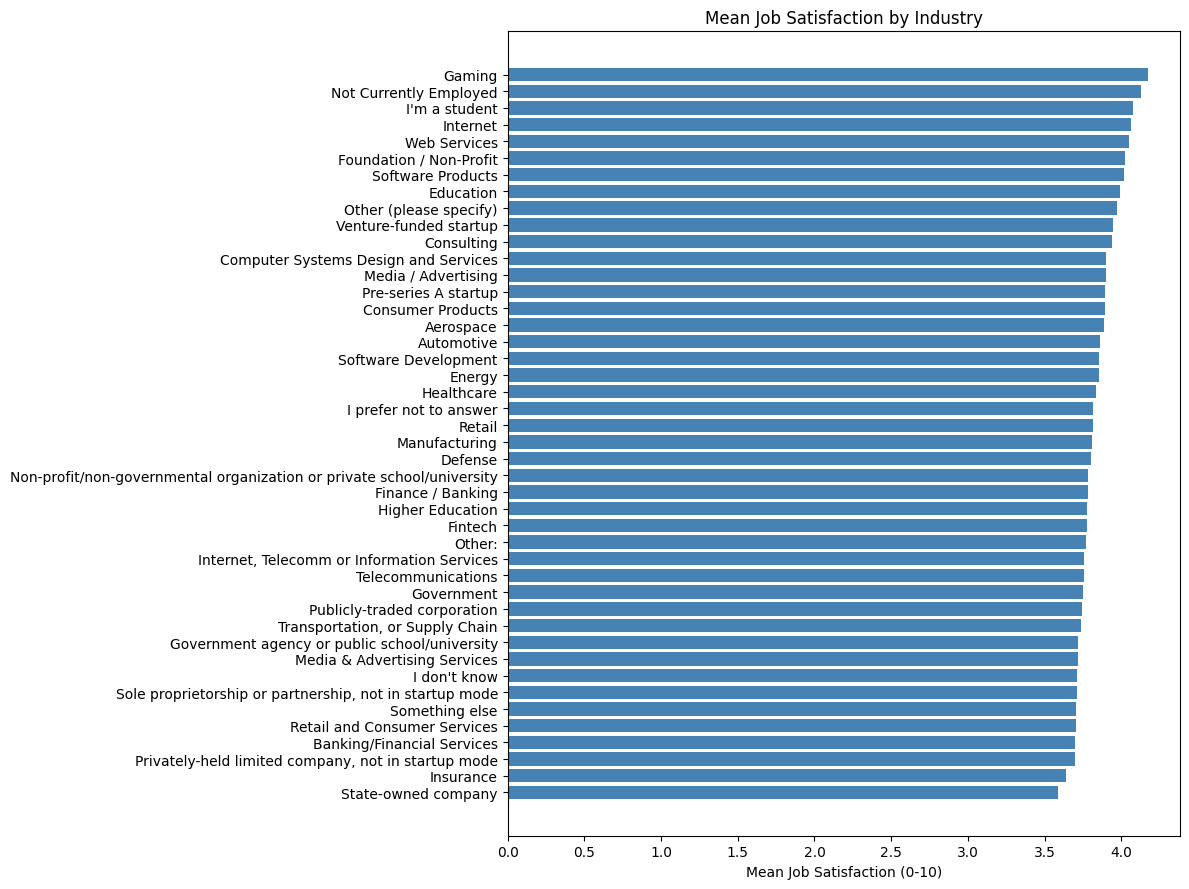

In [46]:
industry_sat = (
    df_model[df_model['industry'].notna()]
    .groupby('industry')['job_sat_std']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 9))
ax.barh(industry_sat['industry'], industry_sat['job_sat_std'], color='steelblue')
ax.set_title('Mean Job Satisfaction by Industry')
ax.set_xlabel('Mean Job Satisfaction (0-10)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [47]:
cols_to_drop = [
    # Non-features
    "row_id",
    "country_clean",       # too granular; region already captures geography

    # Raw target variants (keep job_sat_std)
    "job_sat",
    "job_sat_num",         # 71.5% null

    # Redundant — raw versions superseded by cleaned columns
    "age",                 # 100% null in 2017; use age_group
    "employment",          # use employment_group
    "education",           # use education_clean
    "org_size",            # use org_size_clean
    "remote",              # use remote_group
    "years_code",          # use years_code_clean

    # Redundant compensation columns (keep log_comp_real_2025)
    "comp",
    "comp_usd_clean",
    "log_comp_usd_clean",
    "comp_real_2025",

    # Raw multi-select strings (keep *_count columns)
    "language",
    "database",
    "platform",
]

df_model = df_model.drop(columns=[c for c in cols_to_drop if c in df_model.columns])
print(f"Columns remaining: {len(df_model.columns)}")
print(df_model.columns.tolist())


Columns remaining: 31
['survey_year', 'region', 'age_group', 'employment_group', 'is_employed', 'is_professional', 'education_clean', 'org_size_clean', 'dev_type', 'industry', 'remote_group', 'language_count', 'database_count', 'platform_count', 'years_code_clean', 'years_code_pro', 'professional_experience_years', 'log_comp_real_2025', 'role_family_count', 'role_back_end', 'role_data_ml', 'role_desktop_enterprise', 'role_devops_cloud', 'role_front_end', 'role_full_stack', 'role_management', 'role_mobile', 'role_other', 'role_qa_testing', 'role_student_academic', 'job_sat_std']


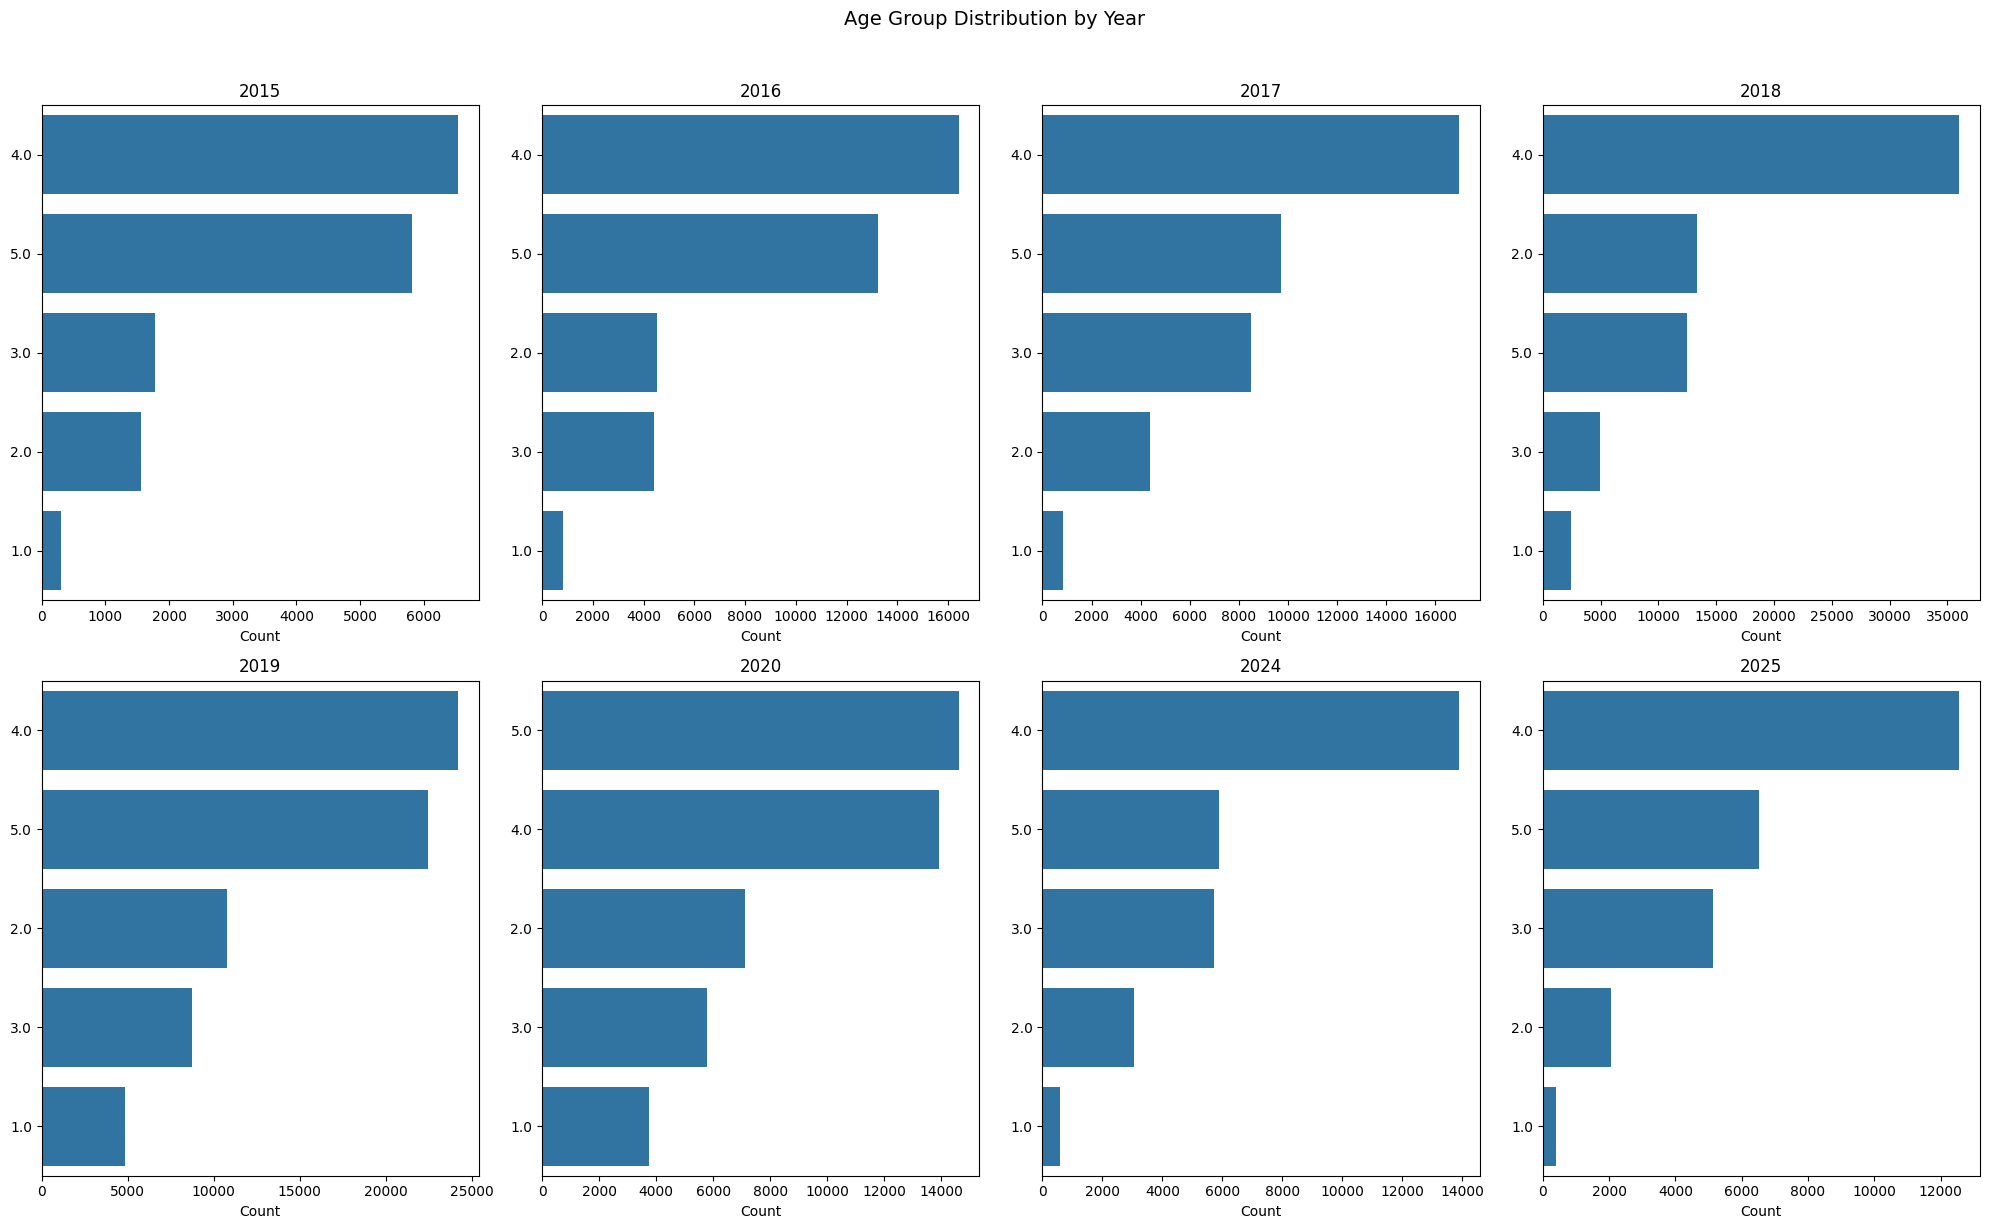

In [48]:
years = sorted(df_model['survey_year'].unique())
n = len(years)
fig, axes = plt.subplots(2, (n + 1) // 2, figsize=(20, 12))
axes = axes.flatten()

for ax, year in zip(axes, years):
    df_year = df_model[df_model['survey_year'] == year]
    order = df_year['job_sat_std'].value_counts().index
    sns.countplot(data=df_year, y='job_sat_std', order=order, ax=ax)
    ax.set_title(str(year))
    ax.set_xlabel("Count")
    ax.set_ylabel("")

# Hide any unused subplots
for ax in axes[n:]:
    ax.set_visible(False)

plt.suptitle("Age Group Distribution by Year", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


In [49]:
EDU_MAP = {
    "Primary/elementary school":    "Below secondary",
    "Secondary school":             "Below secondary",
    "No formal education / other":  "Below secondary",
    "Other / ungrouped":            "Below secondary",
    "Some college/university":      "Some college",
    "Associate degree":             "Some college",
    "Bachelor's degree":            "Bachelor's",
    "Master's degree":              "Postgraduate",
    "Professional degree":          "Postgraduate",
    "Doctoral degree":              "Postgraduate",
}

df_model["education_clean"] = (
    df_model["education_clean"]
    .map(EDU_MAP)
    .fillna("Unknown")
)

print(df_model["education_clean"].value_counts())
print()
print(df_model.groupby("survey_year")["education_clean"].value_counts().unstack(fill_value=0))


education_clean
Bachelor's         138838
Postgraduate        90191
Below secondary     57414
Some college        43928
Unknown              6688
Name: count, dtype: int64

education_clean  Bachelor's  Below secondary  Postgraduate  Some college  \
survey_year                                                                
2015                   4956             6248          2172          1363   
2016                      0            32866          3322          1322   
2017                  18902             3046         11990          6086   
2018                  33459             4988         19467         10305   
2019                  34301             4254         20955         10225   
2020                  21988             2352         13593          6439   
2024                  13126             1942          9815          4243   
2025                  12106             1718          8877          3945   

education_clean  Unknown  
survey_year               
2015        

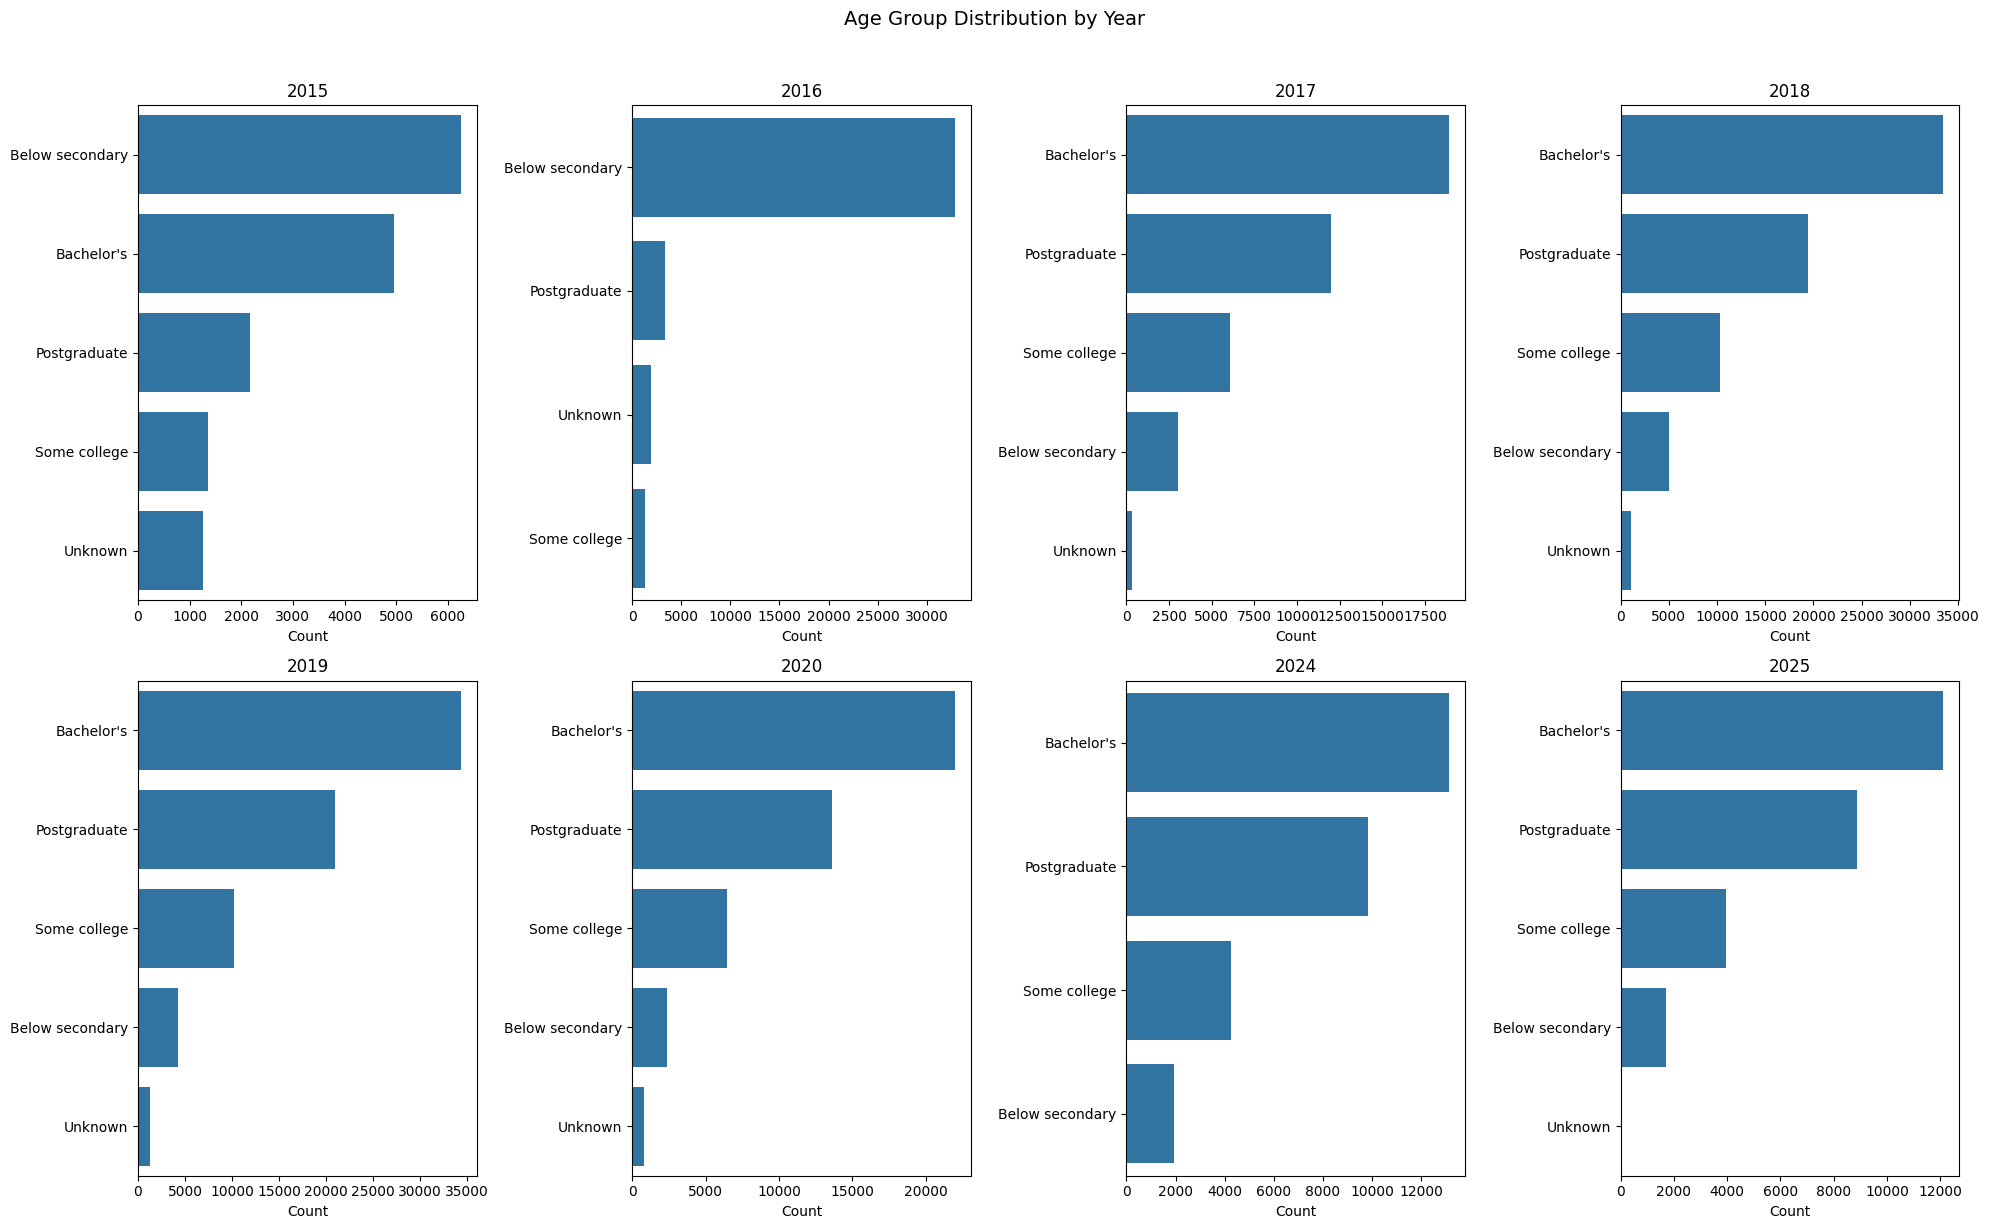

In [50]:
years = sorted(df_model['survey_year'].unique())
n = len(years)
fig, axes = plt.subplots(2, (n + 1) // 2, figsize=(20, 12))
axes = axes.flatten()

for ax, year in zip(axes, years):
    df_year = df_model[df_model['survey_year'] == year]
    order = df_year['education_clean'].value_counts().index
    sns.countplot(data=df_year, y='education_clean', order=order, ax=ax)
    ax.set_title(str(year))
    ax.set_xlabel("Count")
    ax.set_ylabel("")

# Hide any unused subplots
for ax in axes[n:]:
    ax.set_visible(False)

plt.suptitle("Age Group Distribution by Year", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006292 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 494
[LightGBM] [Info] Number of data points in the train set: 269647, number of used features: 26
[LightGBM] [Info] Start training from score 3.733081
Training until validation scores don't improve for 50 rounds
[100]	valid_0's l2: 1.20732
[200]	valid_0's l2: 1.20582
[300]	valid_0's l2: 1.20509
[400]	valid_0's l2: 1.20474
Early stopping, best iteration is:
[373]	valid_0's l2: 1.20462
RMSE: 1.098
R2:   0.044
QWK (rounded predictions): 0.080


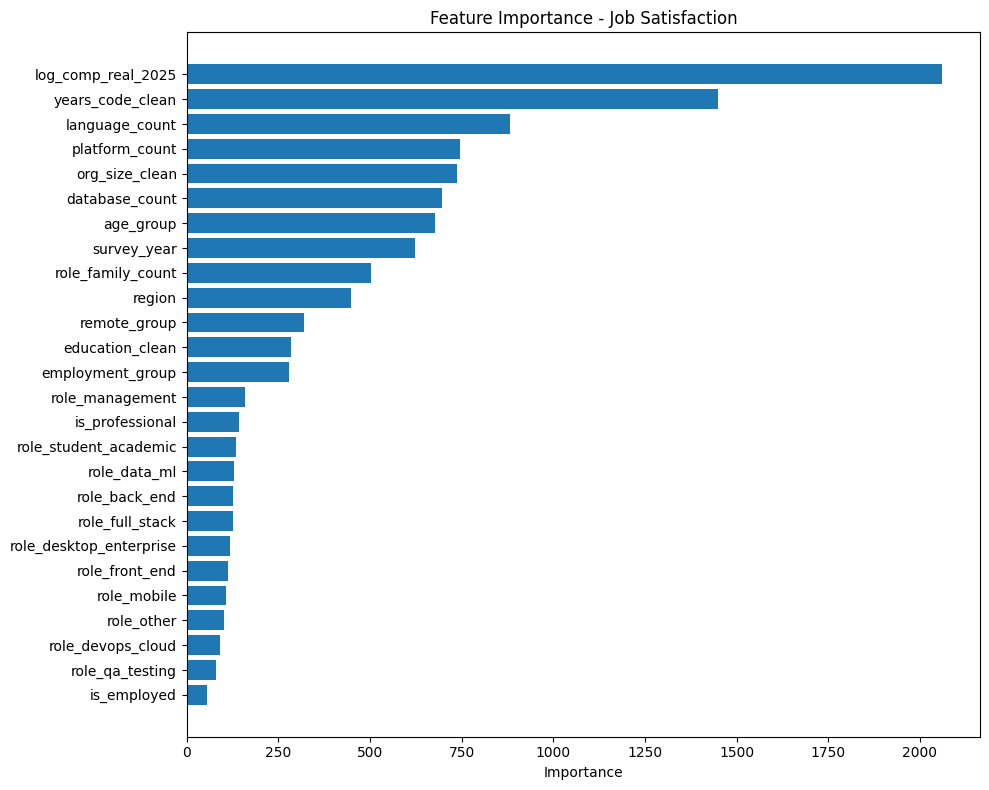

C:\Users\jdric\AppData\Roaming\Python\Python314\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\jdric\AppData\Roaming\Python\Python314\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\jdric\AppData\Roaming\Python\Python314\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capital

In [51]:
# --- Features ---
cat_features = [
    'survey_year', 'region', 'age_group', 'education_clean',
    'employment_group', 'org_size_clean', 'remote_group'
]
num_features = [
    'is_employed', 'is_professional',
    'years_code_clean',
    'language_count', 'database_count', 'platform_count',
    'log_comp_real_2025',
    'role_family_count',
    'role_back_end', 'role_data_ml', 'role_desktop_enterprise',
    'role_devops_cloud', 'role_front_end', 'role_full_stack',
    'role_management', 'role_mobile', 'role_other',
    'role_qa_testing', 'role_student_academic'
]
features = cat_features + num_features
target = 'job_sat_std'

X = df_model[features].copy()
y = df_model[target]

# Convert categoricals for LightGBM
for col in cat_features:
    X[col] = X[col].astype('category')

# --- Train/test split ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# --- Train ---
model = lgb.LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42,
    n_jobs=-1
)
model.fit(X_train, y_train,
          eval_set=[(X_test, y_test)],
          callbacks=[lgb.early_stopping(50), lgb.log_evaluation(100)])

# --- Evaluate ---
y_pred = model.predict(X_test)
y_pred_rounded = np.clip(np.round(y_pred), 1, 5).astype(int)
y_test_int = y_test.astype(int)

print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.3f}")
print(f"R2:   {r2_score(y_test, y_pred):.3f}")
qwk = cohen_kappa_score(y_test_int, y_pred_rounded, weights='quadratic')
print(f"QWK (rounded predictions): {qwk:.3f}")

# --- Feature importance ---
importance = (pd.DataFrame({'feature': features,
                             'importance': model.feature_importances_})
              .sort_values('importance', ascending=True))

plt.figure(figsize=(10, 8))
plt.barh(importance['feature'], importance['importance'])
plt.title('Feature Importance - Job Satisfaction')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

# Save metrics for comparison
from sklearn.metrics import classification_report as _cr
_rep = _cr(y_test_int, y_pred_rounded, output_dict=True)
results_reg = {
    'rmse':        round(float(np.sqrt(mean_squared_error(y_test, y_pred))), 3),
    'r2':          round(float(r2_score(y_test, y_pred)), 3),
    'qwk':         round(float(cohen_kappa_score(y_test_int, y_pred_rounded, weights='quadratic')), 3),
    'accuracy':    round(_rep['accuracy'], 3),
    'macro_f1':    round(_rep['macro avg']['f1-score'], 3),
    'weighted_f1': round(_rep['weighted avg']['f1-score'], 3),
}


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007988 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 496
[LightGBM] [Info] Number of data points in the train set: 269647, number of used features: 26
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
Training until validation scores don't improve for 50 rounds
[100]	valid_0's multi_logloss: 1.53898
[200]	valid_0's multi_logloss: 1.53521
[300]	valid_0's multi_logloss: 1.5329
[400]	valid_0's multi_logloss: 1.53104
[500]	valid_0's multi_logloss: 1.52938
Did not meet early stopping. Best iteration is:
[500]	valid_0's multi_logloss: 1.52938
                   precision    rec

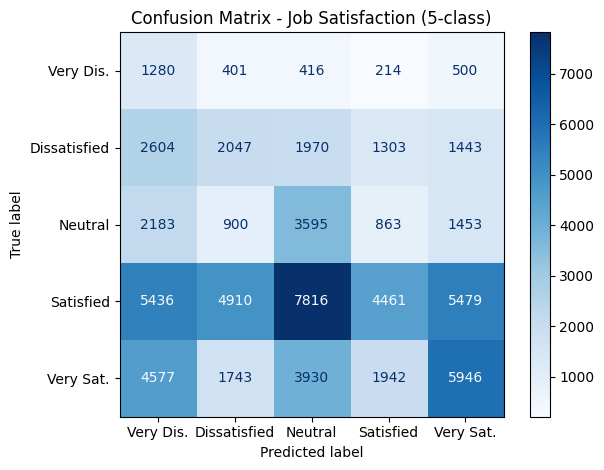

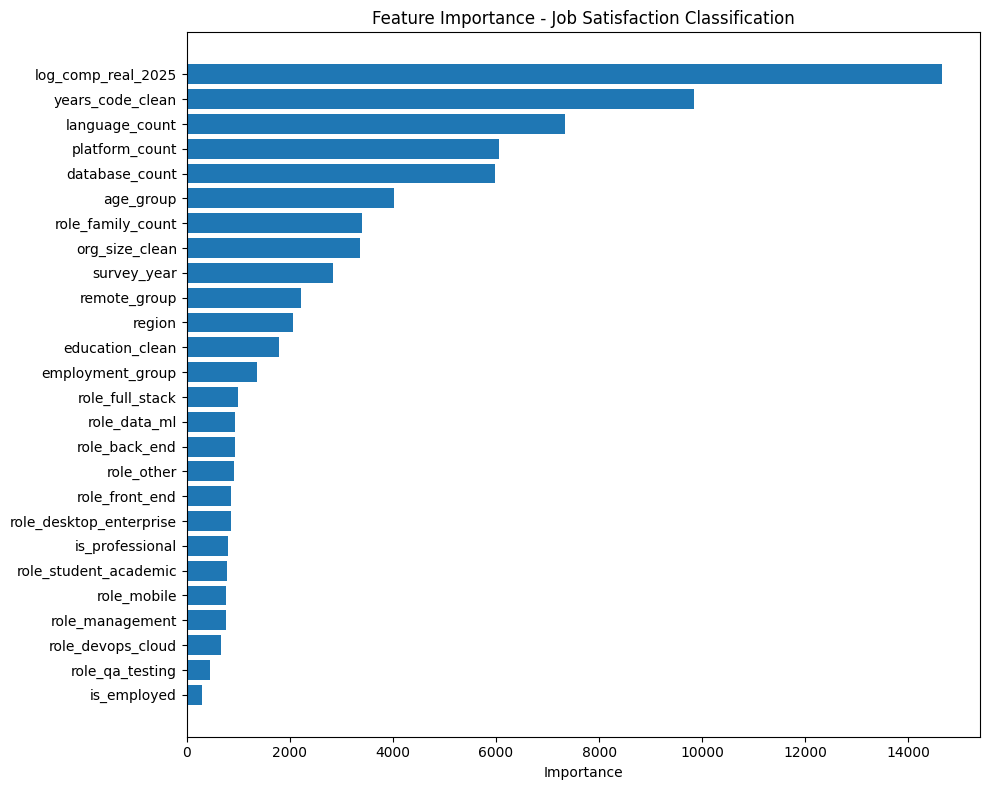

In [52]:
# --- Classification model (5-class ordinal: 1=Very Dissatisfied ... 5=Very Satisfied) ---
SAT_LABELS = [1, 2, 3, 4, 5]

X = df_model[features].copy()
y = df_model['job_sat_std'].astype(int)

for col in cat_features:
    X[col] = X[col].astype('category')

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model_clf = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
model_clf.fit(X_train, y_train,
              eval_set=[(X_test, y_test)],
              callbacks=[lgb.early_stopping(50), lgb.log_evaluation(100)])

# --- Evaluate ---
y_pred = model_clf.predict(X_test)
print(classification_report(y_test, y_pred, labels=SAT_LABELS,
      target_names=['Very Dissatisfied', 'Dissatisfied', 'Neutral', 'Satisfied', 'Very Satisfied']))

qwk = cohen_kappa_score(y_test, y_pred, weights='quadratic', labels=SAT_LABELS)
print(f"Quadratic Weighted Kappa: {qwk:.3f}")

# --- Confusion matrix ---
cm = confusion_matrix(y_test, y_pred, labels=SAT_LABELS)
disp = ConfusionMatrixDisplay(cm, display_labels=['Very Dis.', 'Dissatisfied', 'Neutral', 'Satisfied', 'Very Sat.'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - Job Satisfaction (5-class)')
plt.tight_layout()
plt.show()

# --- Feature importance ---
importance = (pd.DataFrame({'feature': features,
                             'importance': model_clf.feature_importances_})
              .sort_values('importance', ascending=True))

plt.figure(figsize=(10, 8))
plt.barh(importance['feature'], importance['importance'])
plt.title('Feature Importance - Job Satisfaction Classification')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

# Save metrics for comparison
from sklearn.metrics import classification_report as _cr
_rep = _cr(y_test, y_pred, output_dict=True)
results_clf = {
    'accuracy':    round(_rep['accuracy'], 3),
    'macro_f1':    round(_rep['macro avg']['f1-score'], 3),
    'weighted_f1': round(_rep['weighted avg']['f1-score'], 3),
    'qwk':         round(float(cohen_kappa_score(y_test, y_pred, weights='quadratic', labels=SAT_LABELS)), 3),
    'baseline':    round(float(pd.Series(y_test).value_counts(normalize=True).max()), 3),
}


sat_binary
1    231198
0    105861
Name: count, dtype: int64
sat_binary
1    68.6
0    31.4
Name: proportion, dtype: float64
[LightGBM] [Info] Number of positive: 184958, number of negative: 84689
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007854 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 496
[LightGBM] [Info] Number of data points in the train set: 269647, number of used features: 26
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
Training until validation scores don't improve for 50 rounds
[100]	valid_0's binary_logloss: 0.674756
[200]	valid_0's binary_logloss: 0.673557
[300]	valid_0's binary_logloss: 0.672979
[400]	valid_0's binary_logloss: 0.672479
[500]	valid_0's binary_logloss: 0.67204
Did not meet early stopping. Best iteration is:
[500]

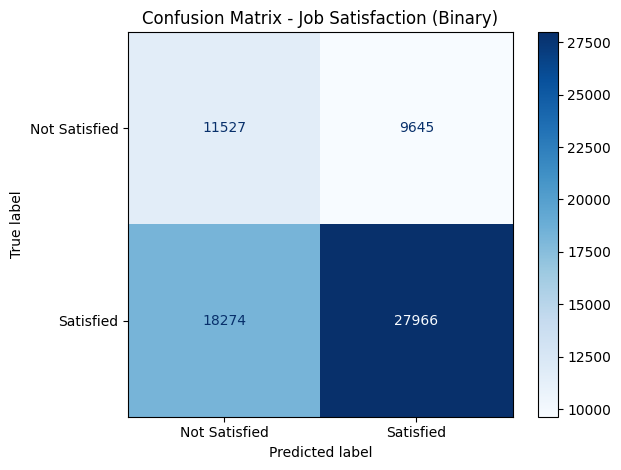

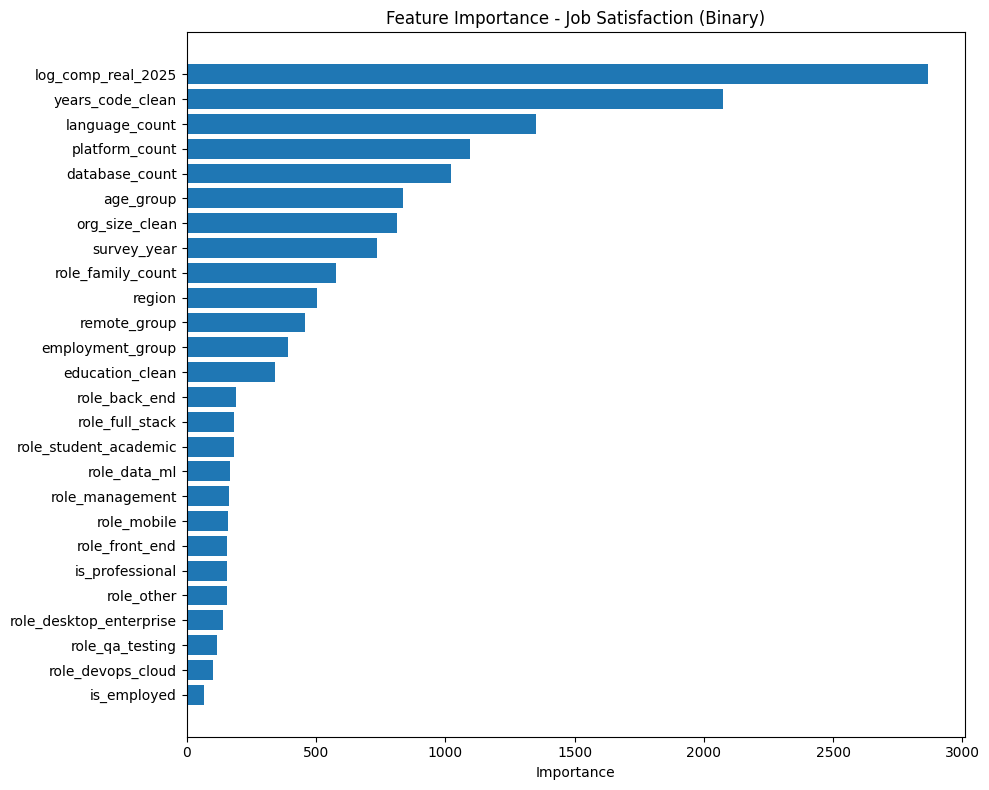

In [55]:
# --- Binary satisfaction ---
df_model['sat_binary'] = (df_model['job_sat_std'] >= 4).astype(int)
print(df_model['sat_binary'].value_counts())
print(df_model['sat_binary'].value_counts(normalize=True).mul(100).round(1))

# --- Train/test split ---
X = df_model[features].copy()
y = df_model['sat_binary']

for col in cat_features:
    X[col] = X[col].astype('category')

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# --- Train ---
model_bin = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    class_weight='balanced',   # add this
    random_state=42,
    n_jobs=-1
)
model_bin.fit(X_train, y_train,
              eval_set=[(X_test, y_test)],
              callbacks=[lgb.early_stopping(50), lgb.log_evaluation(100)])

# --- Evaluate ---
y_pred = model_bin.predict(X_test)
print(classification_report(y_test, y_pred, target_names=['Not Satisfied', 'Satisfied']))

qwk = cohen_kappa_score(y_test, y_pred, weights='quadratic')
print(f"Quadratic Weighted Kappa: {qwk:.3f}")

# --- Confusion matrix ---
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['Not Satisfied', 'Satisfied'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - Job Satisfaction (Binary)')
plt.tight_layout()
plt.show()

# --- Feature importance ---
importance = (pd.DataFrame({'feature': features,
                             'importance': model_bin.feature_importances_})
              .sort_values('importance', ascending=True))

plt.figure(figsize=(10, 8))
plt.barh(importance['feature'], importance['importance'])
plt.title('Feature Importance - Job Satisfaction (Binary)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

# Save metrics for comparison
from sklearn.metrics import classification_report as _cr
_rep = _cr(y_test, y_pred, output_dict=True)
results_bin = {
    'accuracy':    round(_rep['accuracy'], 3),
    'macro_f1':    round(_rep['macro avg']['f1-score'], 3),
    'weighted_f1': round(_rep['weighted avg']['f1-score'], 3),
    'qwk':         round(float(cohen_kappa_score(y_test, y_pred, weights='quadratic')), 3),
    'baseline':    round(float(pd.Series(y_test).value_counts(normalize=True).max()), 3),
}


In [56]:
# --- Model Comparison Table ---
comparison = pd.DataFrame([
    {
        'Model':       'Regression (1-5)',
        'Target':      '1-5 continuous',
        'Accuracy':    results_reg['accuracy'],
        'Macro F1':    results_reg['macro_f1'],
        'Weighted F1': results_reg['weighted_f1'],
        'RMSE':        results_reg['rmse'],
        'R2':          results_reg['r2'],
        'QWK':         results_reg['qwk'],
        'Baseline':    '-',
    },
    {
        'Model':       '5-class Classification',
        'Target':      '1-5 ordinal classes',
        'Accuracy':    results_clf['accuracy'],
        'Macro F1':    results_clf['macro_f1'],
        'Weighted F1': results_clf['weighted_f1'],
        'RMSE':        '-',
        'R2':          '-',
        'QWK':         results_clf['qwk'],
        'Baseline':    results_clf['baseline'],
    },
    {
        'Model':       'Binary Classification',
        'Target':      'satisfied / not (>=3)',
        'Accuracy':    results_bin['accuracy'],
        'Macro F1':    results_bin['macro_f1'],
        'Weighted F1': results_bin['weighted_f1'],
        'RMSE':        '-',
        'R2':          '-',
        'QWK':         results_bin['qwk'],
        'Baseline':    results_bin['baseline'],
    },
])

display(comparison.set_index('Model'))


,Target,Accuracy,Macro F1,Weighted F1,RMSE,R2,QWK,Baseline
Model,,,,,,,,
Regression (1-5),1-5 continuous,0.384,0.149,0.261,1.098,0.044,0.080,-
5-class Classification,1-5 ordinal classes,0.257,0.244,0.269,-,-,0.110,0.417
Binary Classification,satisfied / not (>=3),0.586,0.560,0.600,-,-,0.134,0.686
